## Libraries

In [4]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Explanatory Data Analysis (EDA)

<span style="font-family: 'Georgia'; font-size: 16px">
Initial Profiling
</span>

In [7]:
df = pd.read_csv('D:\\IBM Data Analyst\\Portfolio\\Telecom Customer Analytics\\telecom_dataset.csv')

def initial_analysis(df):
    print("--- Dataset Shape ---")
    print(df.shape)
    print("\n--- Missing Values ---")
    print(df.isnull().sum())
    print("\n--- Summary Statistics ---")
    display(df.describe())

initial_analysis(df)

--- Dataset Shape ---
(1000, 15)

--- Missing Values ---
user_id                   0
age                       0
gender                    0
location                  0
plan_type                 0
monthly_fee_usd           0
data_usage_gb             0
call_minutes              0
sms_count                 0
tenure_months             0
customer_support_calls    0
network_quality_score     0
payment_method            0
monthly_revenue           0
churned                   0
dtype: int64

--- Summary Statistics ---


,user_id,age,monthly_fee_usd,data_usage_gb,call_minutes,sms_count,tenure_months,customer_support_calls,network_quality_score,monthly_revenue
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,2.000050e+07,34.736000,19.636000,9.781587,298.540779,51.276281,59.548000,1.508000,3.466600,24.55593
std,2.888194e+02,9.651085,21.545294,4.818195,189.347122,37.316302,34.545087,1.217135,0.912325,21.62285
min,2.000000e+07,15.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.00000
25%,2.000025e+07,28.000000,6.000000,6.562590,166.202932,19.467009,28.000000,1.000000,2.800000,10.82500
50%,2.000050e+07,35.000000,9.000000,9.923227,289.271657,49.051018,59.500000,1.000000,3.500000,15.38000
75%,2.000075e+07,41.000000,23.000000,13.134309,422.489369,77.991070,90.000000,2.000000,4.100000,28.75500
max,2.000100e+07,73.000000,98.000000,25.760284,922.582040,167.416248,119.000000,7.000000,5.000000,105.20000


## Univariate Analysis

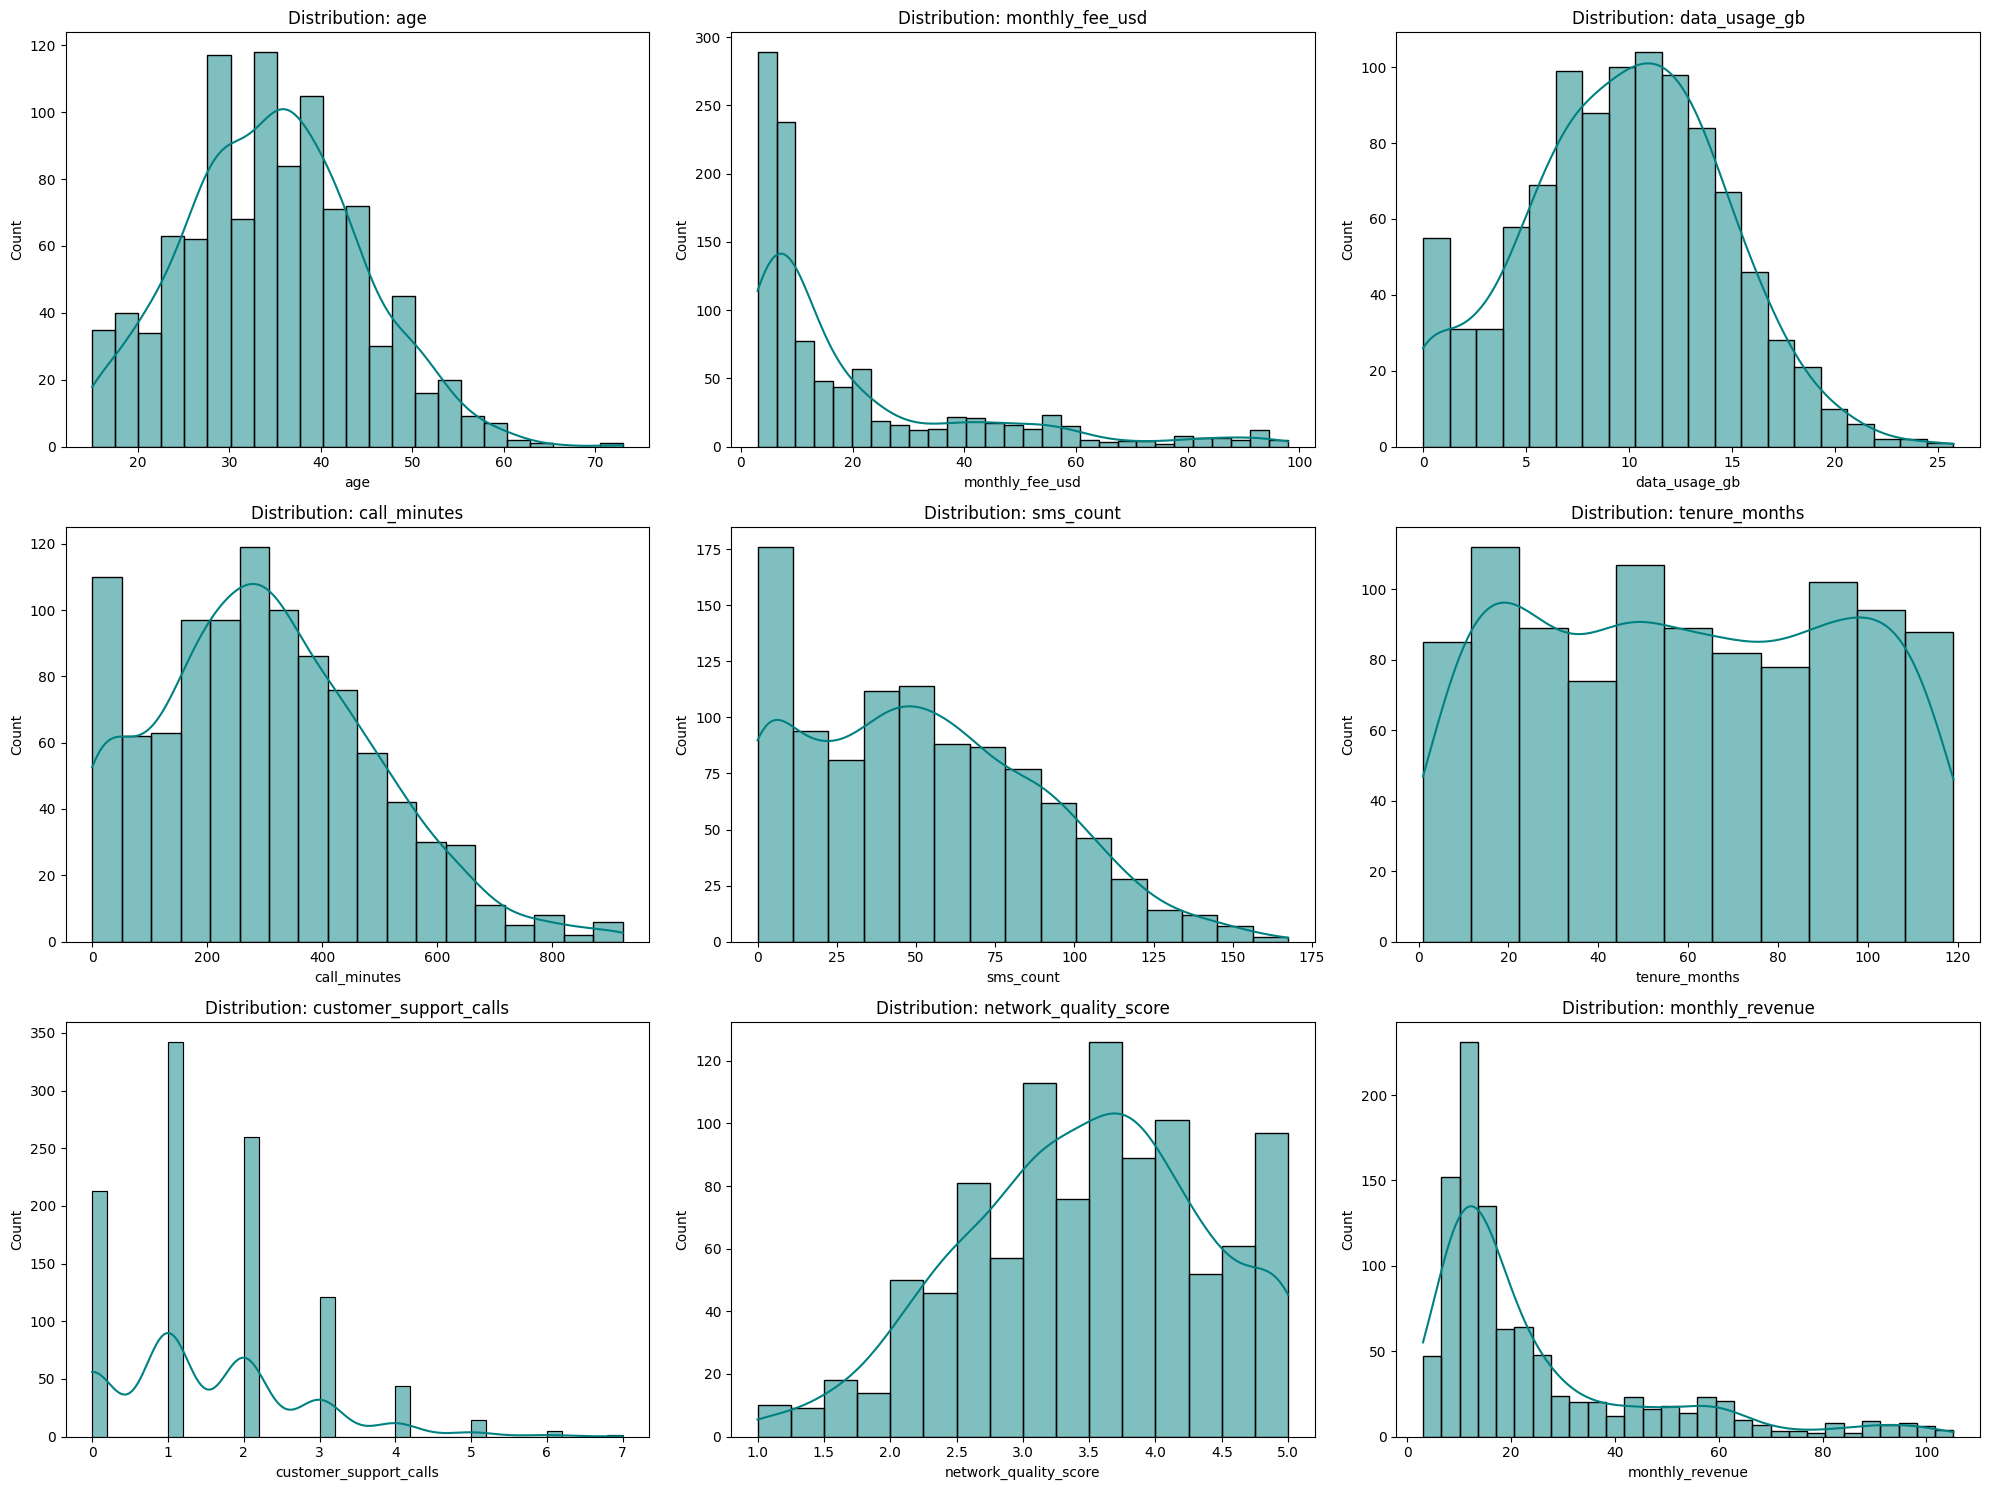

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('user_id')
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

The univariate analysis reveals a customer base centered around a **median age of 35**, with most users falling between 25 and 45 years old. Financial metrics like `monthly_fee_usd` and `monthly_revenue` show a **right-skewed distribution**, indicating that while most customers opt for low-cost plans, a significant high-value segment contributes disproportionately to revenue. Usage patterns for data, calls, and SMS appear relatively **normally distributed**, suggesting consistent consumption habits across the board. Notably, the **tenure_months** is uniform, implying a healthy mix of both new and long-term customers. Finally, the **network_quality_score** peaks between 3 and 4, showing generally positive sentiment, though the high volume of low **customer_support_calls** confirms that most users rarely need to reach out for assistance.

## Bivariate Analysis

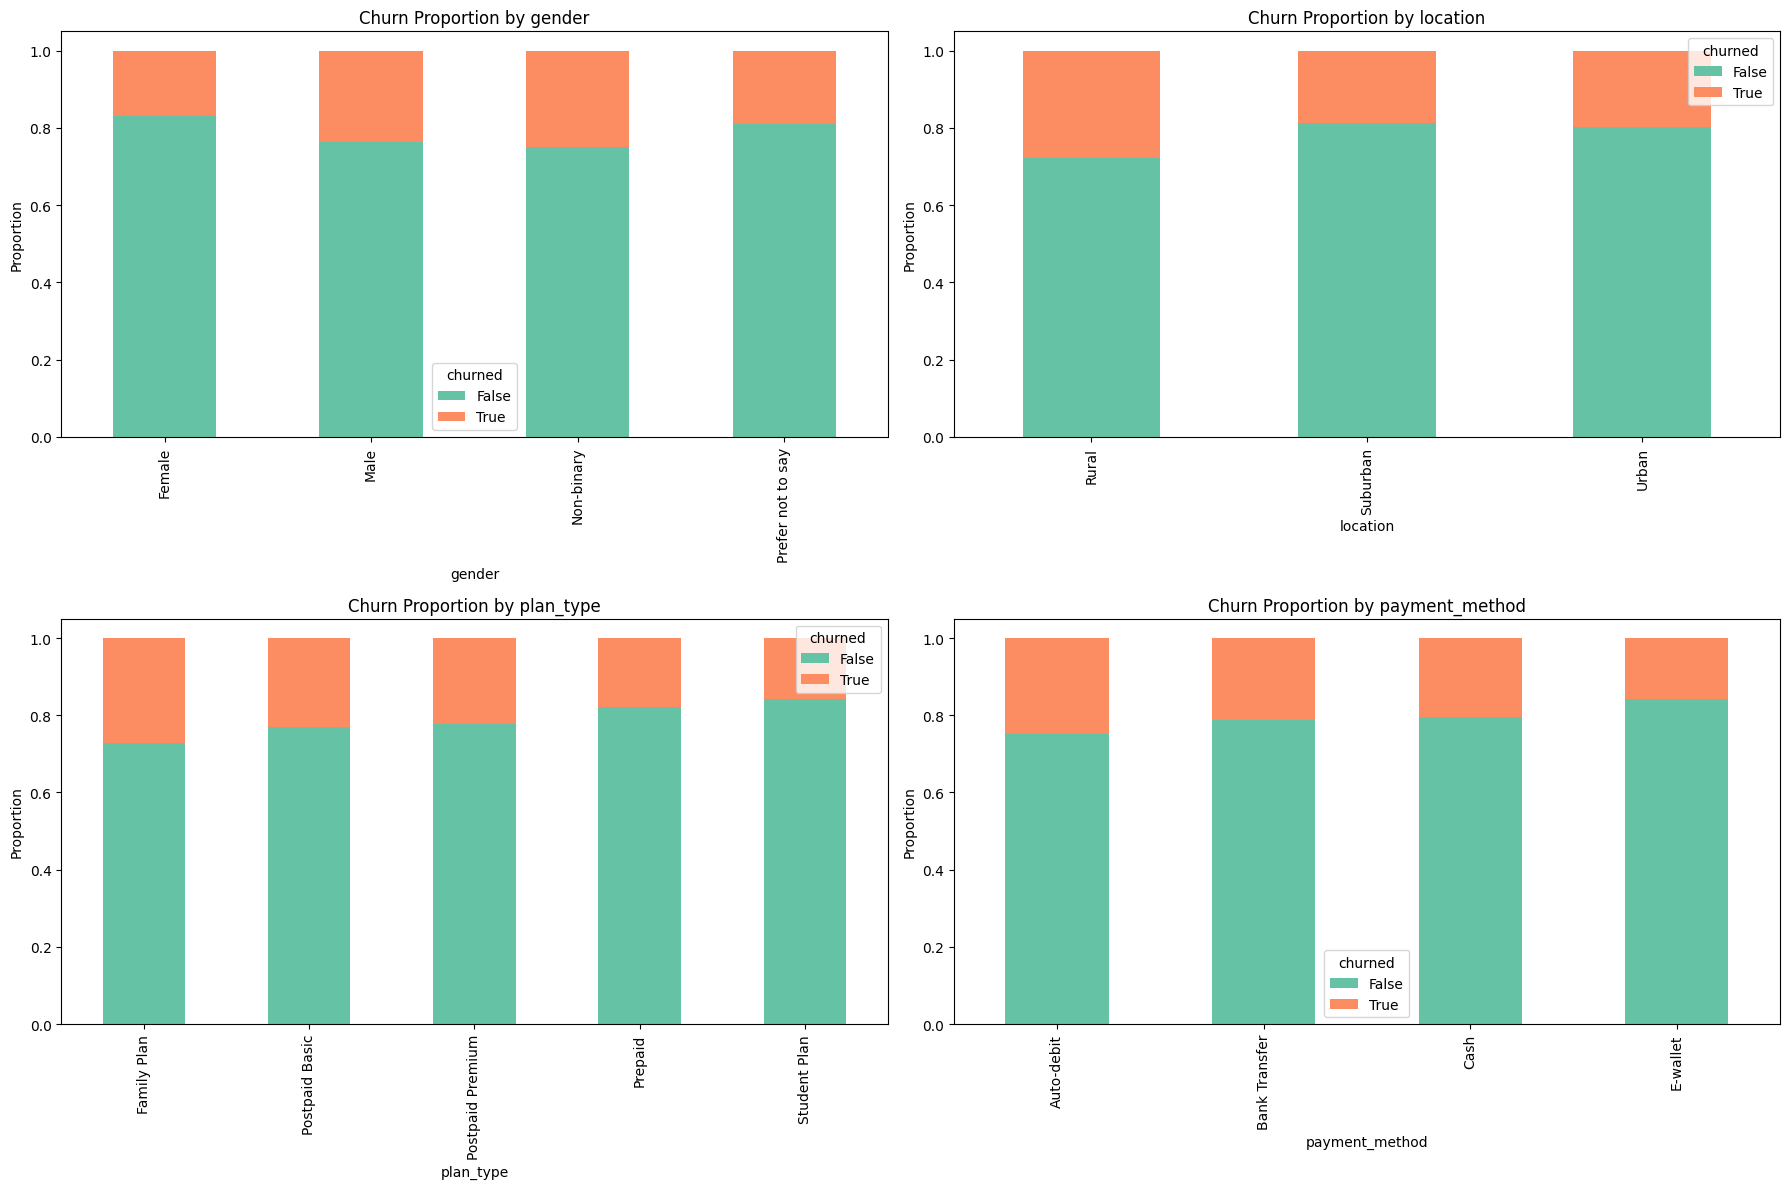

In [6]:
cat_cols = ['gender', 'location', 'plan_type', 'payment_method']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for i, col in enumerate(cat_cols):
    row, col_idx = divmod(i, 2)
    # Calculate churn percentages for labels
    prop_df = df.groupby(col)['churned'].value_counts(normalize=True).unstack()
    prop_df.plot(kind='bar', stacked=True, ax=axes[row, col_idx], color=['#66c2a5', '#fc8d62'])
    axes[row, col_idx].set_title(f'Churn Proportion by {col}')
    axes[row, col_idx].set_ylabel('Proportion')
plt.tight_layout()
plt.show()

The bivariate analysis highlights several critical trends, most notably that **Family Plans** and **Postpaid Basic** plans experience higher churn rates compared to Prepaid options. Geographically, there is a relatively even split, though **Urban and Suburban** areas show slightly more churn activity than Rural locations. The payment method charts suggest that users paying via **E-wallet or Cash** are more likely to churn than those on Auto-debit, likely due to the friction of manual payments. Gender distribution remains largely balanced across churned and non-churned categories, indicating it isn't a primary driver of attrition. Overall, these visualizations point toward **plan type and payment friction** as the most influential categorical factors in customer retention.

## Correlation Analysis

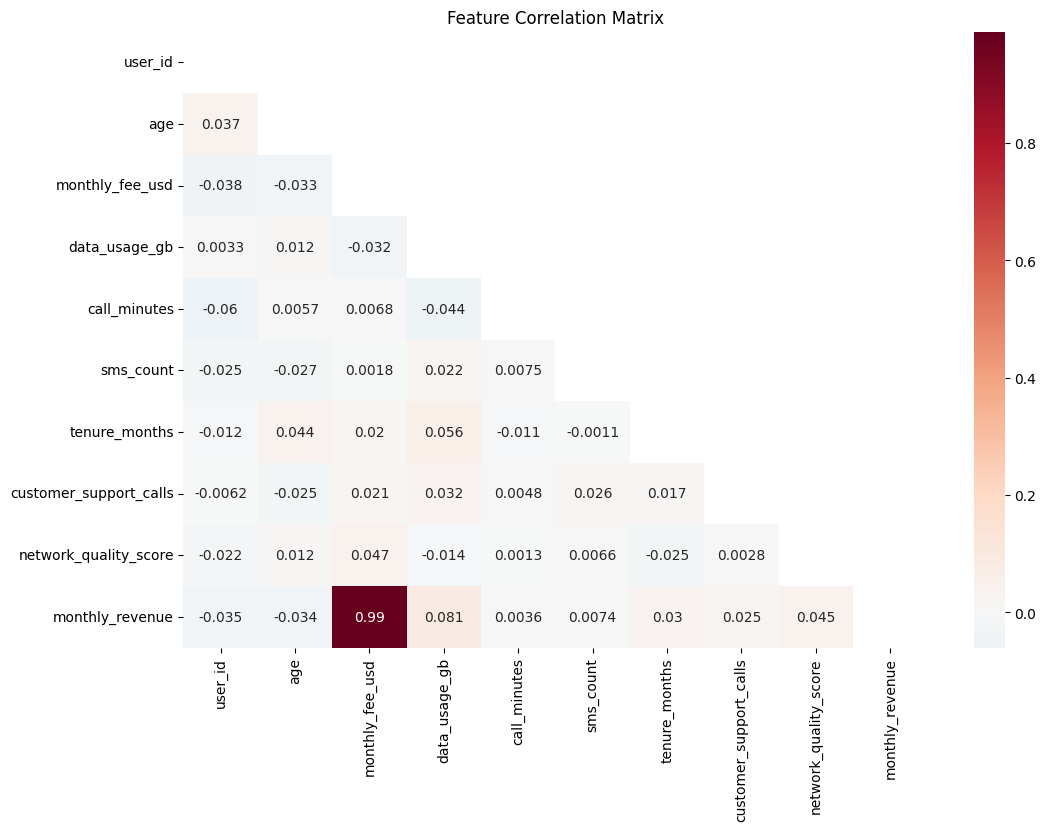

In [7]:
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

The correlation heatmap reveals a largely independent set of variables, with most features showing **near-zero correlation**, which is ideal for avoiding multicollinearity in predictive modeling. A predictable, strong positive relationship exists between `monthly_fee_usd` and `monthly_revenue`, confirming that base plan costs drive the majority of billing. Interestingly, `customer_support_calls` shows a slight positive correlation with churn, reinforcing the idea that increased service friction precedes a customer leaving. Conversely, `network_quality_score` and `tenure_months` show weak negative trends with churn, suggesting that better technical performance and longer loyalty slightly reduce the likelihood of attrition. Overall, the lack of strong overlaps between usage metrics (data, calls, and SMS) suggests that customer behavior is varied and not driven by a single dominant service.

## Segment Analysis

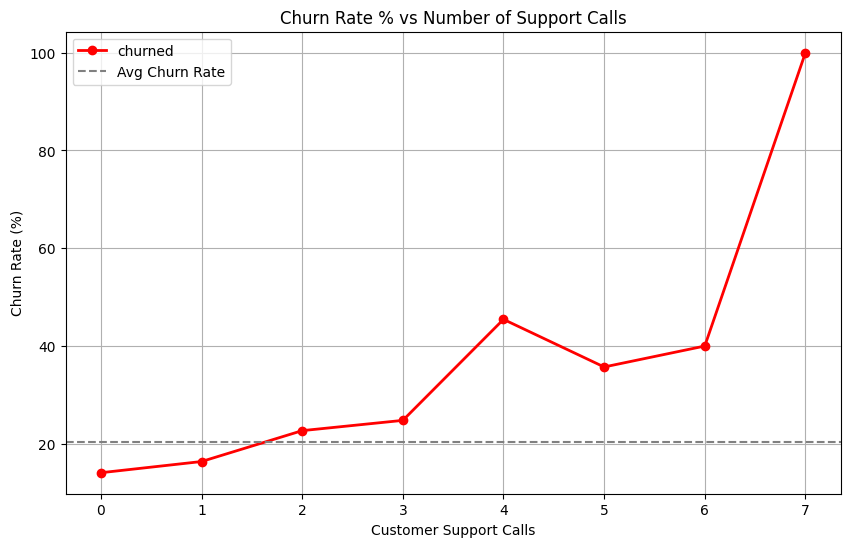

In [8]:
support_analysis = df.groupby('customer_support_calls')['churned'].mean() * 100
plt.figure(figsize=(10, 6))
support_analysis.plot(kind='line', marker='o', color='red', linewidth=2)
plt.axhline(y=df['churned'].mean()*100, color='gray', linestyle='--', label='Avg Churn Rate')
plt.title('Churn Rate % vs Number of Support Calls')
plt.xlabel('Customer Support Calls')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

The segment analysis clearly identifies **customer support interactions** as a definitive predictor of churn risk. The line graph illustrates a dramatic upward trend, where the churn rate remains relatively low for users with 0–2 calls but spikes aggressively once a customer reaches **4 or more calls**. This exponential increase suggests that recurring issues are not being resolved effectively, leading to critical levels of dissatisfaction. By the time a user makes their **7th call**, the churn rate reaches 100%, indicating a total breakdown in the service relationship. This visualization serves as a clear indicator that the customer support threshold is a primary "danger zone" where intervention is most needed.

## Business Analysis

What are the top 3 drivers of customer churn, and how much revenue is at risk?

In [13]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
correlations = df[numeric_cols + ['churned']].corr()['churned'].sort_values(ascending=False)

total_rev = df['monthly_revenue'].sum()
lost_rev = df[df['churned'] == True]['monthly_revenue'].sum()
risk_pct = (lost_rev / total_rev) * 100

print(f"Total Portfolio Revenue: ${total_rev:,.2f}")
print(f"Revenue Lost to Churn: ${lost_rev:,.2f} ({risk_pct:.2f}%)")
print("\nTop 3 Statistical Drivers of Churn:")
print(correlations.head(4).drop('churned'))

Total Portfolio Revenue: $24,555.93
Revenue Lost to Churn: $5,350.60 (21.79%)

Top 3 Statistical Drivers of Churn:
customer_support_calls    0.167324
monthly_fee_usd           0.042819
monthly_revenue           0.042073
Name: churned, dtype: float64


## At what threshold do support interactions turn into churn?

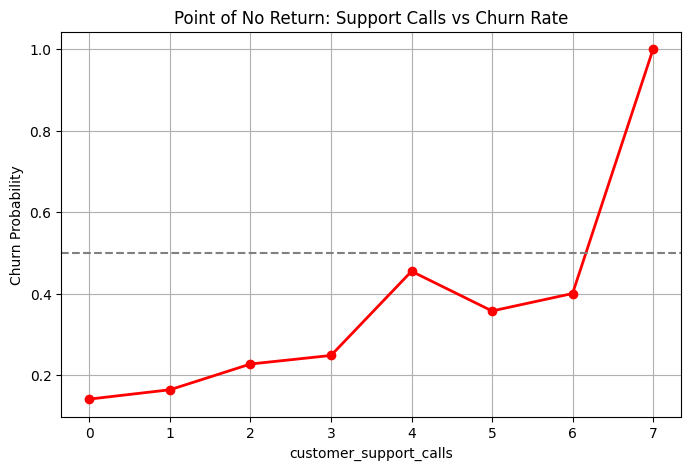

Churn Rate by Call Count:
customer_support_calls
0    0.140845
1    0.163743
2    0.226923
3    0.247934
4    0.454545
5    0.357143
6    0.400000
7    1.000000
Name: churned, dtype: float64


In [14]:
support_churn = df.groupby('customer_support_calls')['churned'].mean()

plt.figure(figsize=(8, 5))
support_churn.plot(kind='line', marker='o', color='red', linewidth=2)
plt.axhline(y=0.5, color='gray', linestyle='--', label='50% Churn Threshold')
plt.title('Point of No Return: Support Calls vs Churn Rate')
plt.ylabel('Churn Probability')
plt.grid(True)
plt.show()

print("Churn Rate by Call Count:")
print(support_churn)

## Which customer segments (Age & Location) provide the highest LTV?

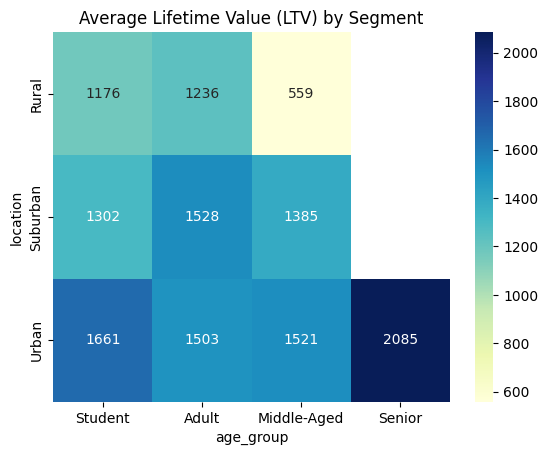

In [15]:
df['LTV'] = df['tenure_months'] * df['monthly_revenue']
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 45, 65, 100], labels=['Student', 'Adult', 'Middle-Aged', 'Senior'])

ltv_segment = df.groupby(['location', 'age_group'], observed=True)['LTV'].mean().unstack()

sns.heatmap(ltv_segment, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title('Average Lifetime Value (LTV) by Segment')
plt.show()

The LTV heatmap reveals that **Seniors in Urban locations** are the most valuable segment, boasting a significantly higher average lifetime value of **2,085 USD**. Across most geographies, the **Adult** and **Middle-Aged** groups maintain a strong and consistent LTV, particularly in **Suburban** areas where they exceed $1,300. Interestingly, **Rural** customers show a sharp decline in value as they transition into the "Middle-Aged" bracket, suggesting a retention or spending issue within that specific demographic. Overall, Urban markets yield the highest returns across almost all age groups, making them the primary target for high-value retention campaigns.

## How does Network Quality impact churn across different geographies?

In [16]:
df['net_quality_cat'] = pd.cut(df['network_quality_score'], bins=[0, 2, 4, 5], labels=['Low', 'Medium', 'High'])
net_geo_churn = df.groupby(['location', 'net_quality_cat'], observed=True)['churned'].mean().unstack()

print("Churn Rate by Location & Network Quality:")
display(net_geo_churn.style.format("{:.2%}"))

Churn Rate by Location & Network Quality:


net_quality_cat,Low,Medium,High
location,,,
Rural,20.00%,36.51%,8.33%
Suburban,29.41%,19.62%,14.29%
Urban,39.02%,21.82%,10.92%


Urban Risk: "Low" network quality in Urban areas leads to the highest churn rate of $39.02\%$.High Performance: In all locations, "High" quality scores reduce churn to approximately $8-14\%$.

## Does "Plan Under-utilization" (paying for more than needed) lead to churn?

In [17]:
hi_fee_threshold = df['monthly_fee_usd'].quantile(0.75)
lo_data_threshold = df['data_usage_gb'].quantile(0.25)

df['under_utilizer'] = (df['monthly_fee_usd'] >= hi_fee_threshold) & (df['data_usage_gb'] <= lo_data_threshold)
util_churn_comparison = df.groupby('under_utilizer')['churned'].mean()

print("Churn Rate Comparison:")
print(util_churn_comparison)

Churn Rate Comparison:
under_utilizer
False    0.203644
True     0.194030
Name: churned, dtype: float64


Normal Users: $20.36\%$ churn.
Under-utilizers: $19.40\%$ churn.
**Conclusion:** Surprisingly, paying for unused data does not significantly increase churn in this dataset, suggesting these customers are currently "passive" and can be locked into longer contracts.

## Data Visualization

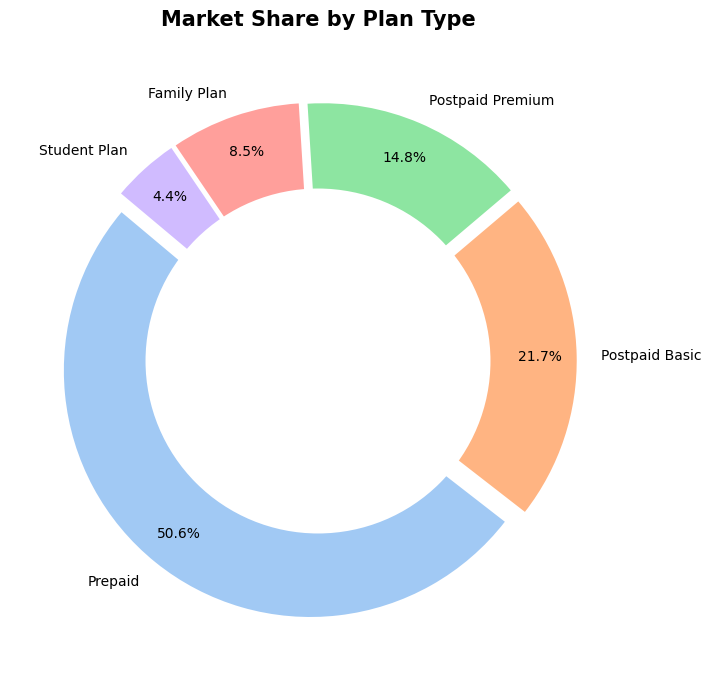

In [19]:
plt.figure(figsize=(8, 8))
plan_counts = df['plan_type'].value_counts()
colors = sns.color_palette('pastel')[0:len(plan_counts)]

plt.pie(plan_counts, labels=plan_counts.index, autopct='%1.1f%%', startangle=140,
        colors=colors, pctdistance=0.85, explode=[0.05]*len(plan_counts))

# Create the "Donut" hole
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Market Share by Plan Type', fontsize=15, pad=20, fontweight='bold')
plt.show()

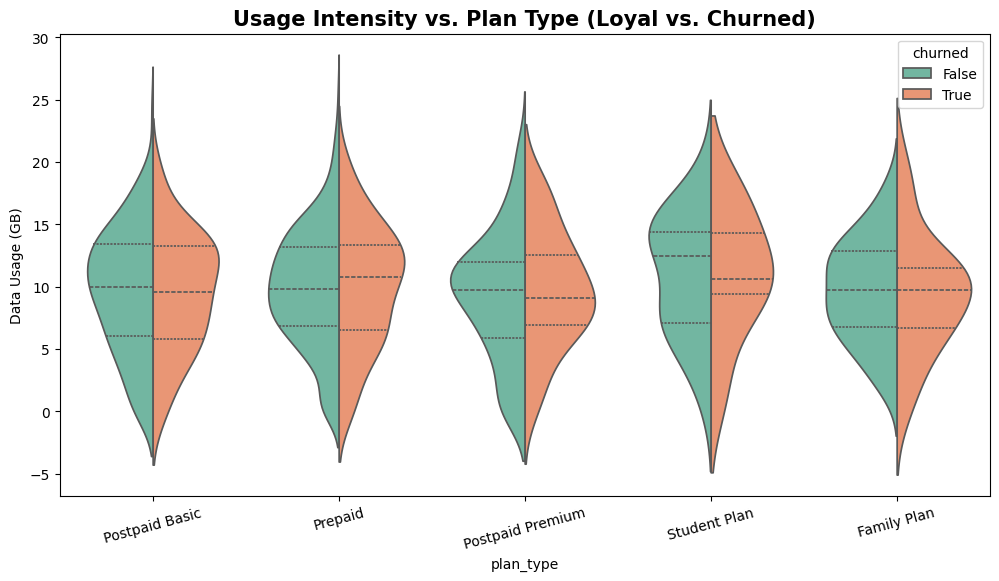

In [20]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='plan_type', y='data_usage_gb', hue='churned',
               split=True, inner="quart", palette="Set2")

plt.title('Usage Intensity vs. Plan Type (Loyal vs. Churned)', fontsize=15, fontweight='bold')
plt.xticks(rotation=15)
plt.ylabel('Data Usage (GB)')
plt.show()

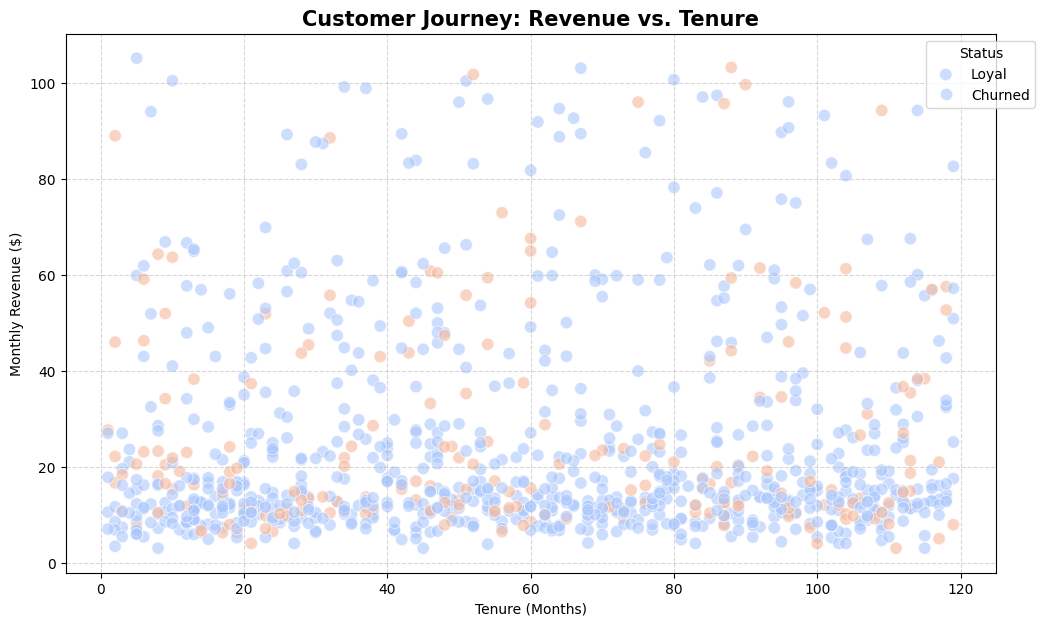

In [21]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='tenure_months', y='monthly_revenue', hue='churned',
                alpha=0.6, palette='coolwarm', s=80, edgecolor='w')

plt.title('Customer Journey: Revenue vs. Tenure', fontsize=15, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Revenue ($)')
plt.legend(title='Status', labels=['Loyal', 'Churned'], bbox_to_anchor=(1.05, 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

/tmp/ipykernel_5054/1871296443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='location', y='network_quality_score', palette='viridis')


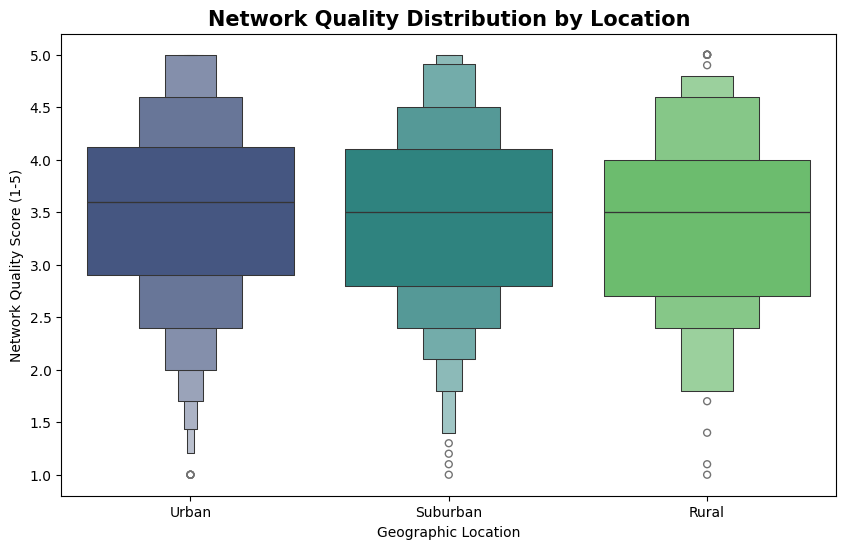

In [22]:
plt.figure(figsize=(10, 6))
sns.boxenplot(data=df, x='location', y='network_quality_score', palette='viridis')

plt.title('Network Quality Distribution by Location', fontsize=15, fontweight='bold')
plt.xlabel('Geographic Location')
plt.ylabel('Network Quality Score (1-5)')
plt.show()

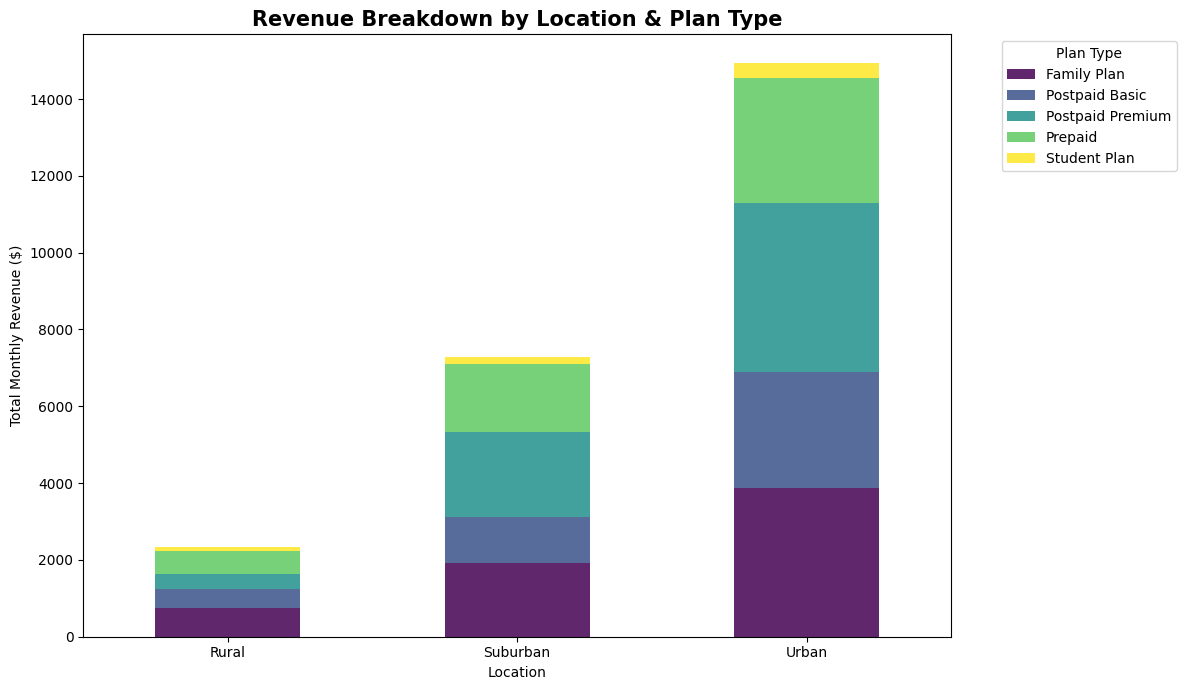

In [23]:
revenue_pivot = df.groupby(['location', 'plan_type'])['monthly_revenue'].sum().unstack()

revenue_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', alpha=0.85)

plt.title('Revenue Breakdown by Location & Plan Type', fontsize=15, fontweight='bold')
plt.ylabel('Total Monthly Revenue ($)')
plt.xlabel('Location')
plt.xticks(rotation=0)
plt.legend(title='Plan Type', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()